# Sistem Rekomendasi Varietas Tanaman Hortikultura
**Algoritma:** Random Forest  
**Objektif:** Merekomendasikan varietas tanaman berdasarkan kondisi lingkungan (pH, Suhu, Curah Hujan, dll).

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [2]:
# Load data mentah
df_raw = pd.read_csv('data/dataset_training_random_forest.csv')
print(f"Total Data: {len(df_raw)} baris")
df_raw.head()

Total Data: 810 baris


,Nama_Tanaman,Kecamatan,pH_Tanah,Suhu_C,Curah_Hujan_mm,Elevasi_mdpl,Ketersediaan_Air,Intensitas_Matahari_jam,Nama_Varietas
0,Ketimun,Baktiya,6.46,24.2,1763,255,Rendah,6.4,Hercules F1
1,Ketimun,Baktiya,6.46,24.2,1763,255,Rendah,6.4,Mercy F1
2,Ketimun,Baktiya,6.46,24.2,1763,255,Rendah,6.4,Roman F1
3,Kacang Panjang,Baktiya,6.46,24.2,1763,255,Rendah,6.4,Parade Tavi
4,Kacang Panjang,Baktiya,6.46,24.2,1763,255,Rendah,6.4,Kanton Tavi


## 3. Data Preprocessing
Mengubah data kategorikal menjadi numerik agar bisa diolah oleh Random Forest.

In [3]:
df = df_raw.copy()

# 1. Mapping Ketersediaan Air
water_mapping = {'Rendah': 0, 'Sedang': 1, 'Tinggi': 2}
df['Ketersediaan_Air'] = df['Ketersediaan_Air'].map(water_mapping)

# 2. Encoding Label (Varietas, Tanaman, dan Kecamatan)
le_varietas = LabelEncoder()
le_tanaman = LabelEncoder()
le_kecamatan = LabelEncoder()

df['Nama_Varietas_Encoded'] = le_varietas.fit_transform(df['Nama_Varietas'])
df['Nama_Tanaman_Encoded'] = le_tanaman.fit_transform(df['Nama_Tanaman'])
df['Kecamatan_Encoded'] = le_kecamatan.fit_transform(df['Kecamatan'])

print("Preprocessing Selesai!")
df[['Kecamatan', 'Kecamatan_Encoded', 'Nama_Tanaman', 'Nama_Varietas']].head()

Preprocessing Selesai!


,Kecamatan,Kecamatan_Encoded,Nama_Tanaman,Nama_Varietas
0,Baktiya,0,Ketimun,Hercules F1
1,Baktiya,0,Ketimun,Mercy F1
2,Baktiya,0,Ketimun,Roman F1
3,Baktiya,0,Kacang Panjang,Parade Tavi
4,Baktiya,0,Kacang Panjang,Kanton Tavi


## 4. Model Training
Melatih model untuk mengenali kondisi lingkungan dan memprediksi lokasi (Kecamatan).

In [4]:
# Fitur (X) dan Target (y)
features_names = ['pH_Tanah', 'Suhu_C', 'Curah_Hujan_mm', 'Elevasi_mdpl', 'Ketersediaan_Air', 'Intensitas_Matahari_jam']
X = df[features_names]
y = df['Kecamatan_Encoded']

# Split Data 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Inisialisasi & Training Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Training Selesai!")

Training Selesai!


## 5. Evaluasi Model

Akurasi Model: 100.00%


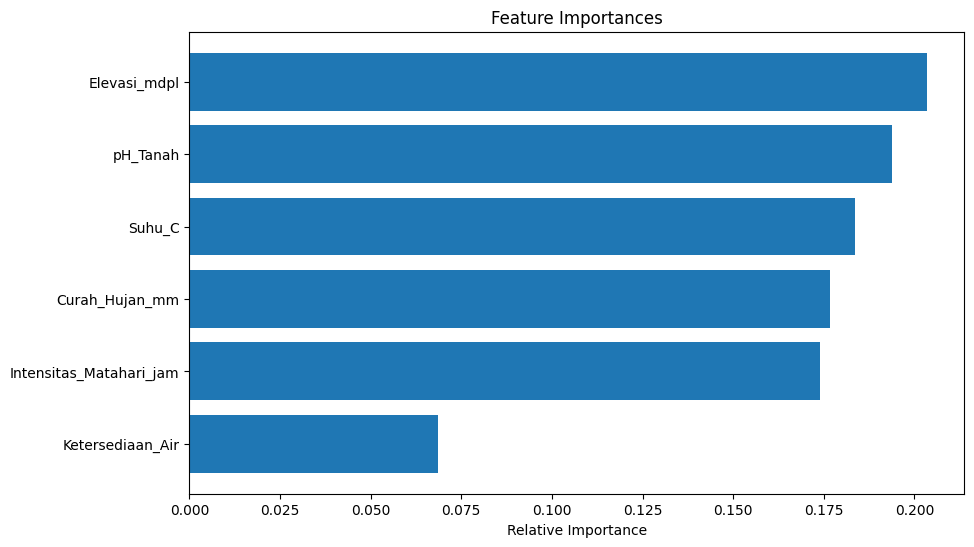

In [5]:
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Akurasi Model: {accuracy * 100:.2f}%")

# Feature Importance Visualization
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## 6. Simulasi Prediksi
Mencoba melakukan prediksi dari input baru.

In [6]:
def recommend(ph, suhu, hujan, elevasi, air, matahari):
    # 1. Predict Kecamatan using DataFrame to avoid UserWarning
    input_df = pd.DataFrame([[ph, suhu, hujan, elevasi, air, matahari]], 
                            columns=['pH_Tanah', 'Suhu_C', 'Curah_Hujan_mm', 
                                     'Elevasi_mdpl', 'Ketersediaan_Air', 'Intensitas_Matahari_jam'])
    
    pred_kec_encoded = rf_model.predict(input_df)[0]
    kec_name = le_kecamatan.inverse_transform([pred_kec_encoded])[0]
    
    # 2. Get recommendations from data
    recs = df[df['Kecamatan'] == kec_name]
    results = recs.groupby('Nama_Tanaman')['Nama_Varietas'].first()
    
    print(f"Hasil Prediksi Lokasi: Kecamatan {kec_name}")
    print("\nRekomendasi Varietas:")
    for plant, variety in results.items():
        print(f"- {plant}: Varietas {variety}")

# Contoh: Menggunakan data Baktiya
recommend(ph=6.46, suhu=24.2, hujan=1763, elevasi=255, air=0, matahari=6.4)

Hasil Prediksi Lokasi: Kecamatan Baktiya

Rekomendasi Varietas:
- Bayam: Varietas Maestro
- Cabe Besar: Varietas Tanjung 2
- Cabe Keriting: Varietas TM 999
- Cabe Rawit: Varietas Dewata F1
- Kacang Panjang: Varietas Parade Tavi
- Kangkung: Varietas Bangkok LP-1
- Ketimun: Varietas Hercules F1
- Semangka: Varietas Crimson Sweet
- Terung: Varietas Mustang F1
- Tomat: Varietas Servo F1
